# Preload Packages

In [40]:
# Limit number of cores
import os
os.nice(19)
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

# Create logger
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.hasHandlers():
    ch = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    ch.setFormatter(formatter)
    logger.addHandler(ch)

### Own packages

In [112]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
import h5py

rootpath = '/home/dneup16/leiden_phd/scripts/GNAT_develop'
if rootpath not in os.sys.path:
    os.sys.path.append(rootpath)

import src.galaxy_alignment_prediction_tool.multipoles
import src.galaxy_alignment_prediction_tool.powerspectrum
import src.galaxy_alignment_prediction_tool.projections
import src.galaxy_alignment_prediction_tool.fitter
import src.galaxy_alignment_prediction_tool.utils
import src.galaxy_alignment_prediction_tool.predictor

# Reload to update changes
import importlib
importlib.reload(src.galaxy_alignment_prediction_tool.multipoles)
importlib.reload(src.galaxy_alignment_prediction_tool.powerspectrum)
importlib.reload(src.galaxy_alignment_prediction_tool.projections)
importlib.reload(src.galaxy_alignment_prediction_tool.fitter)
importlib.reload(src.galaxy_alignment_prediction_tool.utils)
importlib.reload(src.galaxy_alignment_prediction_tool.predictor)

from src.galaxy_alignment_prediction_tool.multipoles import multipoles
from src.galaxy_alignment_prediction_tool.powerspectrum import powerSpectrum
from src.galaxy_alignment_prediction_tool.projections import projections
from src.galaxy_alignment_prediction_tool.fitter import fitter
from src.galaxy_alignment_prediction_tool.utils import ioUtils
from src.galaxy_alignment_prediction_tool.predictor import galaxyAlignmentPredictor

# Initialise classes
fitterHandler = fitter(logger=logger)
ioUtilsHandler = ioUtils(logger=logger)
powerSpectrumHandler = powerSpectrum()
multipolesHandler = multipoles()
projectionsHandler = projections()

# Test individual predictor functions

In [113]:
cosmo_params = {
    'h': 0.67,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'n_s': 0.96,
    'sigma8': 0.8,
}
ccl_cosmo = ccl.Cosmology(**cosmo_params)
redshift_list = np.array([0., 0.5, 1., 1.5])
k_input_single = np.geomspace(1e-5, 500, 1000)
pk_input = np.zeros((len(k_input_single), 2, len(redshift_list)))
k_input = np.tile(k_input_single, (len(redshift_list), 2, 1)).T

for i, redshift in enumerate(redshift_list):
    pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
        cosmo=ccl_cosmo,
        k_input=k_input_single,
        redshift=redshift,
        pk_type='nonlinear_matter'
    )

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=redshift
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=redshift,
        )

    pk_input[:, 0, i] = pkgg
    pk_input[:, 1, i] = pkgp

In [114]:
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list
)

In [115]:
np.shape(k_input)
for idx_z in range(len(redshift_list)-1):
    for idx_meas in range(2):
        assert (k_input[:, idx_meas, idx_z] == k_input[:, idx_meas, idx_z+1]).all()

In [116]:
predictor.initialise_power_spectra(
    k_input=k_input,
    pk_input=pk_input,
    probetype_order=['gg', 'g+']
)

100%|██████████| 4/4 [00:00<00:00, 7105.98it/s]


In [117]:
rhocrit = ccl.physical_constants.RHO_CRITICAL # M_sun/h (Mpc/h)^-3
C1 = 5e-14  # in (h^2 M_sun Mpc^-3)^-1
C1rhocrit = C1 * rhocrit
C1rhocrit

0.013876831360184281

# Test joint predictor functions

In [118]:
cosmo_params = {
    'h': 0.67,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'n_s': 0.96,
    'sigma8': 0.8,
}
ccl_cosmo = ccl.Cosmology(**cosmo_params)
redshift_list = np.arange(0., 2.1, 0.25)
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)

predictor.initialise_all_power_spectra_from_ccl(
    k_bounds=[1e-6, 1000],
    n_k=5000,
)
rp_array = np.geomspace(0.1, 200, 500)/predictor.cosmology['h']  # Mpc
r_array = np.geomspace(0.1, 200, 500)/predictor.cosmology['h']  # Mpc
pi_max = 50/predictor.cosmology['h']  # Mpc
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0.,
    beta_density=0.,
    pi_max=pi_max,
    rp_min=6/cosmo_params['h']
)

2026-07-08 17:10:39,401 - __main__ - INFO - Initialising power spectrum splines for each redshift
100%|██████████| 9/9 [00:00<00:00, 5819.14it/s]
2026-07-08 17:10:39,404 - __main__ - INFO - Done. Splines stored in self.pk_splines_list
2026-07-08 17:10:39,404 - __main__ - INFO - Calculating estimators for each redshift and power spectrum type
100%|██████████| 9/9 [00:01<00:00,  4.55it/s]
2026-07-08 17:10:41,384 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines, self.projection_splines, and self.correlation_splines


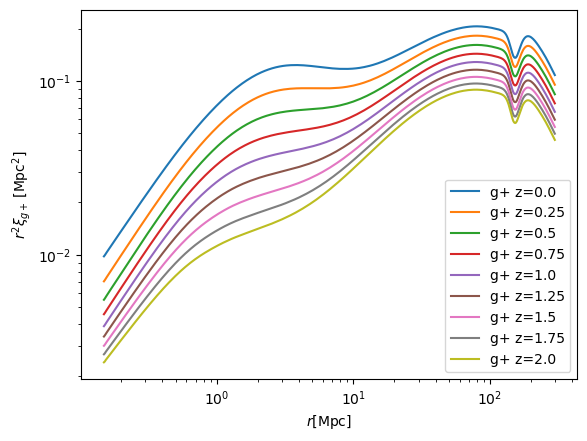

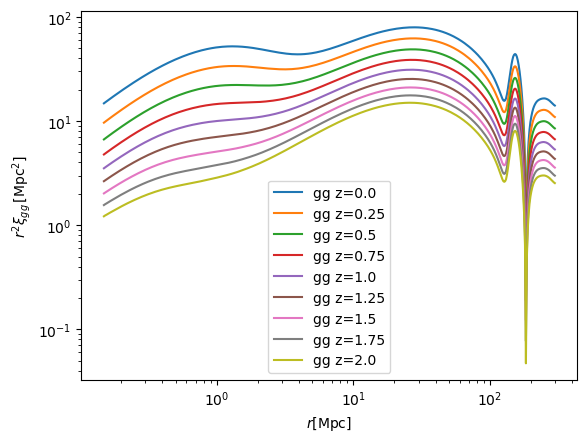

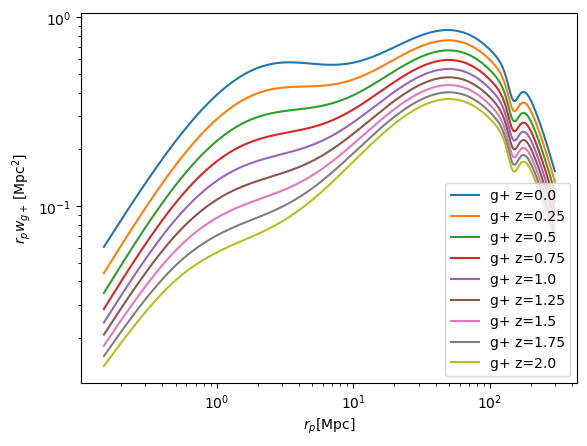

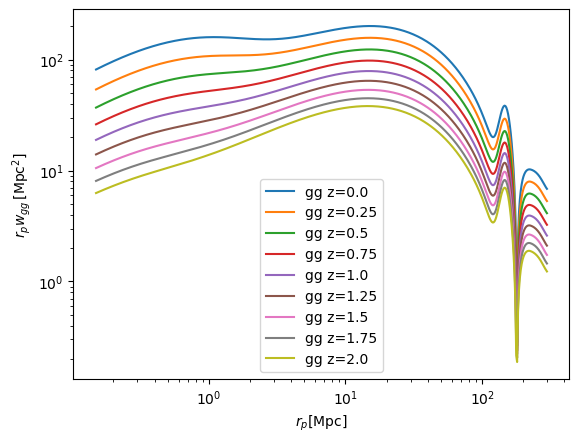

In [119]:
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

xi_gp = xi_arr[:, 0, :, 1]
xi_gg = xi_arr[:, 1, :, 0]
w_gp = w_arr[:, 0, :]
w_gg = w_arr[:, 1, :]

for i_z, z in enumerate(redshift_list):
    plt.loglog(r_array, r_array**2*xi_gp[:, i_z], label=f"g+ z={z}")
plt.xlabel(r"$r [\mathrm{Mpc}]$")
plt.ylabel(r"$r^2 \xi_{g+} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

for i_z, z in enumerate(redshift_list):
    plt.loglog(r_array, np.abs(r_array**2*xi_gg[:, i_z]), label=f"gg z={z}")
plt.xlabel(r"$r [\mathrm{Mpc}]$")
plt.ylabel(r"$r^2 \xi_{gg} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

for i_z, z in enumerate(redshift_list):
    plt.loglog(rp_array, r_array*w_gp[:, i_z], label=f"g+ z={z}")
plt.xlabel(r"$r_p [\mathrm{Mpc}]$")
plt.ylabel(r"$r_p w_{g+} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

for i_z, z in enumerate(redshift_list):
    plt.loglog(rp_array, np.abs(r_array*w_gg[:, i_z]), label=f"gg z={z}")
plt.xlabel(r"$r_p [\mathrm{Mpc}]$")
plt.ylabel(r"$r_p w_{gg} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()



['g+', 'gg', 'spin0', 'spin4']


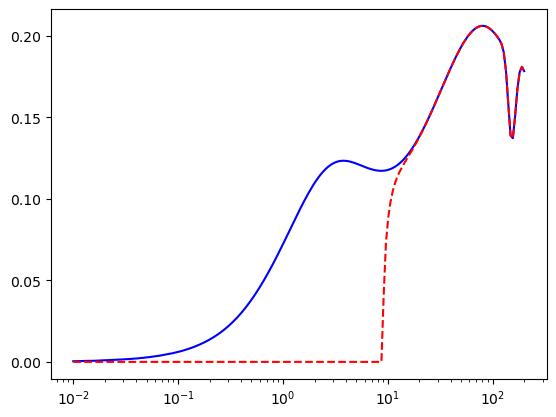

In [120]:
r_support = np.geomspace(1e-2, 200, 200)
print(predictor.probetype_order)
multipole_gp_z0 = predictor.multipole_splines[0][0][2](r_support)
multipole_wedged_gp_z0 = predictor.multipole_wedged_splines[0][0][2](r_support)

plt.semilogx(r_support, r_support**2*multipole_gp_z0, 'b-')
plt.semilogx(r_support, r_support**2*multipole_wedged_gp_z0, 'r--')
plt.show()
plt.close()

In [12]:
xi_gp22_spline = predictor.multipole_splines[0][1][2]
xi_gp22_spline

In [13]:
mu_support=np.geomspace(1e-6, 1, 500)
r_support=np.geomspace(1e-2, 500, 500)
import scipy.special as sp_special
from scipy.interpolate import RectBivariateSpline

# Get the correct spin factor for each pk_type
spin_factors = [0,2,0,4]

# Predefine arrays for xi(r, mu)
correlation_function_spline = []

# Iterate over multipoles to get correlation function
# Predefine xi_2d_array for this redshift and pk_type
xi_2d_array = np.zeros((len(r_support), len(mu_support)))

xi_ell_interp_dict = predictor.multipole_splines[0][0]
ell_list = list(xi_ell_interp_dict.keys())

for ell in ell_list:
    xi_ell_array = xi_ell_interp_dict[ell](r_support)  # shape (len(r_support),)
    P_ell_mu = sp_special.assoc_legendre_p(ell, spin_factors[1], mu_support)[0]  # shape (len(mu_support),)
    print(np.shape(xi_ell_array[:, None] * P_ell_mu[None, :]))
    xi_2d_array += xi_ell_array[:, None] * P_ell_mu[None, :]  # shape (len(r_support), len(mu_support))

# Create 2D spline
xi_2d_spline = RectBivariateSpline(r_support, mu_support, xi_2d_array)

(500, 500)
(500, 500)
(500, 500)


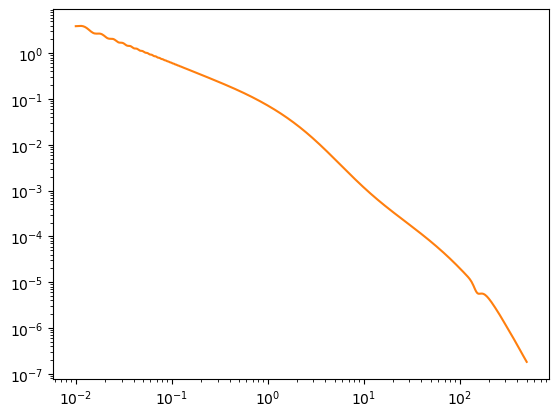

In [14]:
plt.loglog(r_support, xi_ell_interp_dict[0](r_support))
plt.loglog(r_support, xi_ell_interp_dict[2](r_support))
plt.loglog(r_support, xi_ell_interp_dict[4](r_support))

In [15]:
xi_ell_interp_dict[0](r_support)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.